In [13]:
from matplotlib import pyplot as plt
import numpy as np

In [14]:
from sklearn.datasets import make_blobs
X_test,y_test = make_blobs(n_samples= [200,300,500], n_features=2 , centers =[[-1,-1],[0,1],[1,0]])

In [15]:
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

hyperparams = np.array([10, 20,50,100,200,500,1000,2000,5000]) #size of training dataset
metrics_train = np.empty_like(hyperparams, dtype= float)
metrics_test = np.empty_like(hyperparams, dtype= float)

for index, hyperparam in enumerate(hyperparams):
    n_samples = (np.array([0.2,0.3,0.5]) * hyperparam).astype(int)
    X_train,y_train = make_blobs(n_samples= n_samples , n_features=2 , centers =[[-1,-1],[0,1],[1,0]])
    model = DecisionTreeClassifier(criterion = 'entropy', max_depth = 3, min_samples_split = 3)
    model.fit(X_train, y_train)
    metrics_train[index] = accuracy_score(y_train, model.predict(X_train))
    metrics_test[index] = accuracy_score(y_test, model.predict(X_test))



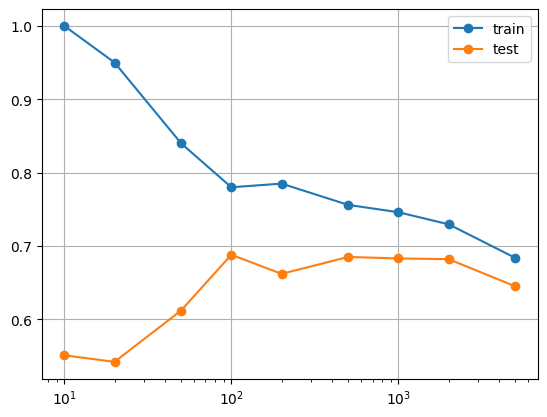

In [16]:
plt.plot(hyperparams, metrics_train ,'o-',label = 'train')
plt.plot(hyperparams, metrics_test ,'o-',label = 'test')
plt.xscale('log')
plt.grid(True)
plt.legend()
plt.show()

In [19]:
# how does the performance of my model depends on max depth
X_train,y_train = make_blobs(n_samples= [200,300,500] , n_features=2 , centers =[[-1,-1],[0,1],[1,0]])

hyperparams = np.array([1,2,4,8,16,32,64]) #maximum depth of tree
metrics_train = np.empty_like(hyperparams, dtype= float)
metrics_test = np.empty_like(hyperparams, dtype= float)

for index, hyperparam in enumerate(hyperparams):
    model = DecisionTreeClassifier(criterion = 'entropy', max_depth = hyperparam, min_samples_split = 2)
    model.fit(X_train, y_train)
    metrics_train[index] = accuracy_score(y_train, model.predict(X_train))
    metrics_test[index] = accuracy_score(y_test, model.predict(X_test))

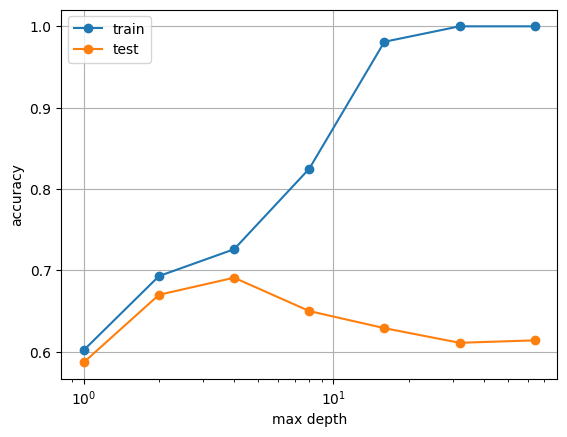

In [21]:
plt.plot(hyperparams, metrics_train ,'o-',label = 'train')
plt.plot(hyperparams, metrics_test ,'o-',label = 'test')
plt.xlabel('max depth')
plt.ylabel('accuracy')
plt.xscale('log')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
#whats happening: at the end we have overfitting because there is a gap between them:big gap it could be a sign of overfitting
# in the beginning we have only one split so the model is not very strong so the accuracy is very low

# the orange curve: at first it goes up: as maximum depth gets higher the model learns more and it goes up but then it goes down because
# when we overfitting at some point it can be a datapoint by some mistake gose to other class cluster and if we overfit than wrong
# classified datapoint will have it's own decision tree around it and new point there will classify wrongly and it's better not to 
# overfit and have simpler tree

In [24]:
# for knn classifier
from sklearn.neighbors import KNeighborsClassifier

hyperparams = np.array([1,2,5,10,20,50,100,200,500,1000]) #k
metrics_train = np.empty_like(hyperparams, dtype= float)
metrics_test = np.empty_like(hyperparams, dtype= float)

for index, hyperparam in enumerate(hyperparams):
    model = KNeighborsClassifier(n_neighbors=hyperparam)
    model.fit(X_train, y_train)
    metrics_train[index] = accuracy_score(y_train, model.predict(X_train))
    metrics_test[index] = accuracy_score(y_test, model.predict(X_test))

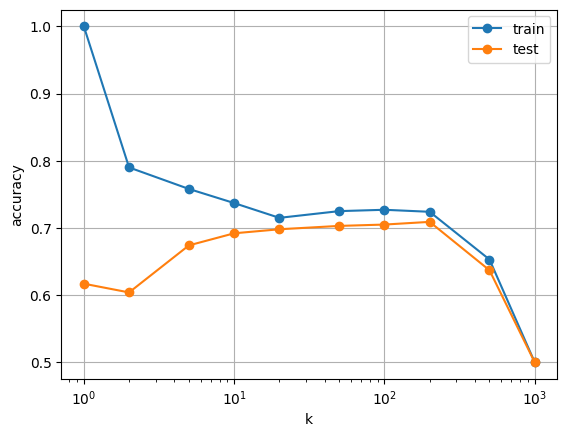

In [26]:
plt.plot(hyperparams, metrics_train ,'o-',label = 'train')
plt.plot(hyperparams, metrics_test ,'o-',label = 'test')
plt.xlabel('k')
plt.ylabel('accuracy')
plt.xscale('log')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# 